# News: tone, topics, and whether news moves price

**The questions.** What is the tone of the news on each market? What is it about?
And does a change in tone come before a price move, after it, or neither?

**The pipeline.**

1. Every stored article's headline and summary is scored by a language model
   (FinBERT), giving the probability that the tone is positive, negative, or neutral.
   The article's score is positive minus negative, from -1 to +1.
2. A second model assigns each article one topic from a fixed list.
3. Scores are averaged per day for each market.
4. Days with unusually strong tone are found, and the price around them is examined.

No article text appears in this notebook. Notebook 06 covers how the tone model was
fine-tuned and tested.

Rebuild with `uv run python backend/scripts/build_notebooks.py 05_news`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sqlalchemy import func, select

from radar.analytics import event_study
from radar.db.models import ModelRegistry, NewsArticle, NewsSentiment, NewsSymbol, NewsTopic, SentimentAggregate
from radar.db.session import make_engine, session_scope
from radar.models import topics
from radar.pipelines import event_study as study_job
from radar.pipelines import sentiment as sentiment_job
from radar.universe import get_universe

plt.rcParams.update({"figure.figsize": (11, 3.4), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
engine, universe = make_engine(), get_universe()
symbols = [a.symbol for a in universe.primary]
version = sentiment_job.active_version(engine)
topic_version = topics.version_of(topics.MODEL_ID)

with session_scope(engine) as session:
    scores = pd.read_sql(
        select(NewsSymbol.symbol, NewsArticle.created_at, NewsSentiment.score, NewsTopic.topic)
        .join(NewsArticle, NewsArticle.id == NewsSymbol.article_id)
        .join(NewsSentiment, NewsSentiment.article_id == NewsArticle.id)
        .outerjoin(NewsTopic, (NewsTopic.article_id == NewsArticle.id) & (NewsTopic.model_version == topic_version))
        .where(NewsSentiment.model_version == version, NewsArticle.duplicate_of.is_(None)),
        session.connection(),
    )
    daily = pd.read_sql(select(SentimentAggregate).where(SentimentAggregate.bucket == "1Day"), session.connection())
    accuracy = session.scalars(
        select(ModelRegistry).where(ModelRegistry.name == sentiment_job.MODEL_NAME, ModelRegistry.is_current)
    ).first().metrics
    studies = {s: study_job.current(session, s).metrics for s in symbols}
    inputs = {a.symbol: study_job.daily_inputs(session, a) for a in universe.primary}
scores["created_at"] = pd.to_datetime(scores["created_at"], utc=True)
print(f"tone model in use: {version}; {len(scores):,} article-market links scored")

tone model in use: finbert-radar-1; 107,095 article-market links scored


## 1. How much news there is

This decides everything that follows. Bitcoin and US stocks have many articles a day.
Gold has one or two, which is too few for some of the analysis, and the app says so.

In [2]:
coverage = pd.DataFrame(
    {
        a.symbol: {
            "measured from": a.news_start,
            "articles": int((scores["symbol"] == a.symbol).sum()),
            "articles per day": (scores["symbol"] == a.symbol).sum()
            / max((pd.Timestamp.now(tz="UTC") - pd.Timestamp(a.news_start, tz="UTC")).days, 1),
        }
        for a in universe.primary
    }
).T
coverage

,measured from,articles,articles per day
BTC/USD,2022-01-01,21428,12.329
GLD,2023-01-01,3300,2.403
SPY,2016-01-01,82367,20.959


## 2. How good is the tone model?

Measured on 200 headlines labelled separately, before any model output for them
existed. The labels were written by an AI model (Claude), not a person. The rival is
counting positive and negative words from a finance word list.

In [3]:
table = {"Tone model": accuracy["model"]}
if "baseline" in accuracy:
    table["Word counting"] = accuracy["baseline"]
if "topics" in accuracy:
    table["Topic model (7 topics)"] = accuracy["topics"]
print("labelled by:", accuracy["labelled_by"])
pd.DataFrame({k: {"headlines": v["n"], "accuracy": v["accuracy"], "macro F1": v["macro_f1"]} for k, v in table.items()}).T

labelled by: ['claude']


,headlines,accuracy,macro F1
Tone model,200.000,0.725,0.729
Word counting,200.000,0.515,0.502
Topic model (7 topics),200.000,0.600,0.489


In [4]:
pd.DataFrame(accuracy["by_symbol"]).T.rename(columns={"n": "headlines"})

,headlines,accuracy,macro_f1
GLD,40.000,0.650,0.661
SPY,80.000,0.725,0.714
BTC/USD,80.000,0.762,0.764


## 3. What the scores look like

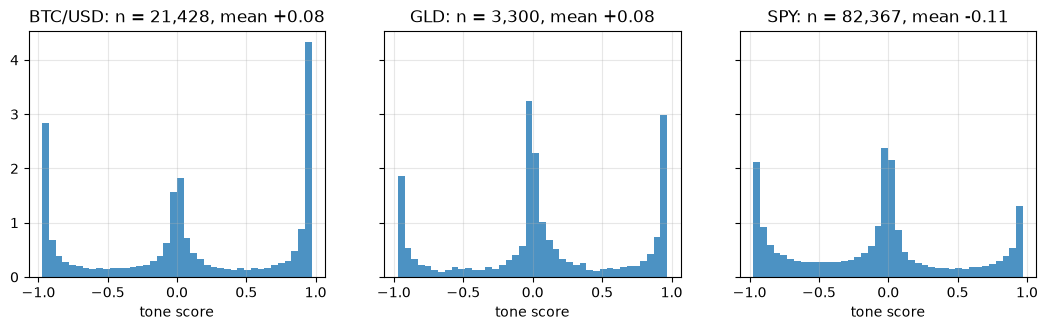

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)
for ax, s in zip(axes, symbols):
    part = scores.loc[scores["symbol"] == s, "score"]
    ax.hist(part, bins=40, color="tab:blue", alpha=0.8, density=True)
    ax.set(title=f"{s}: n = {len(part):,}, mean {part.mean():+.2f}", xlabel="tone score")

Scores pile up near -1, 0, and +1 because the model is usually confident. That is
normal for this kind of model, and is why daily averages are used, not single scores.

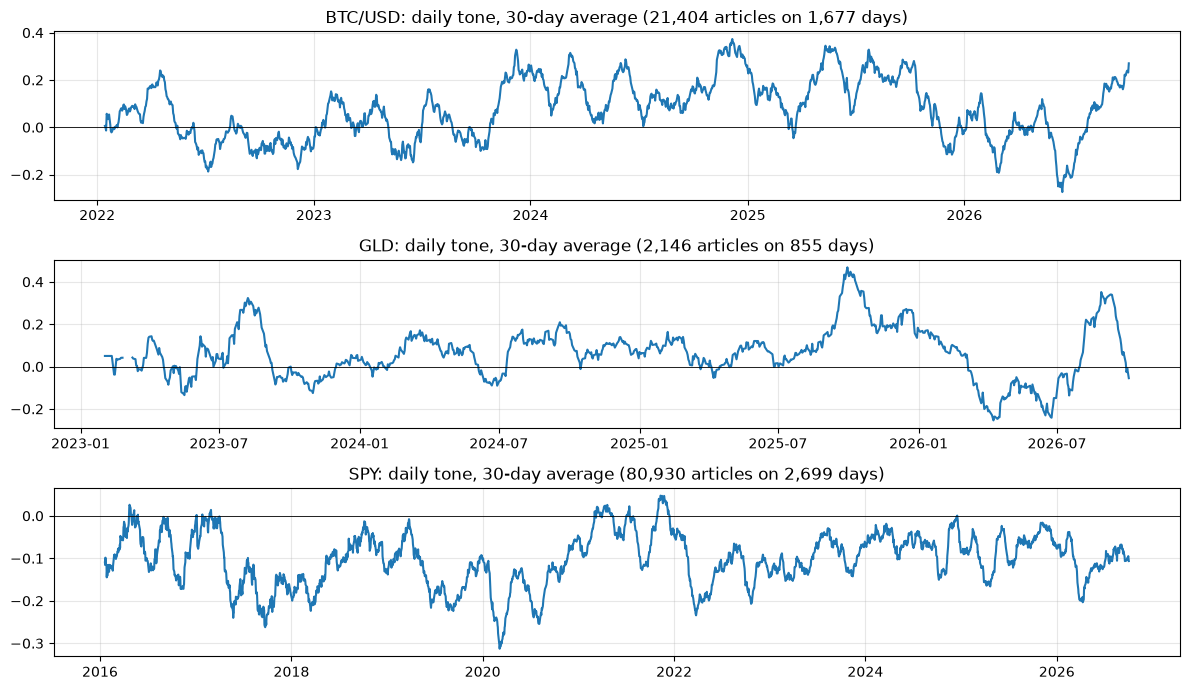

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=False)
for ax, s in zip(axes, symbols):
    part = daily[daily["symbol"] == s].sort_values("ts").set_index("ts")
    smooth = part["score_mean"].rolling(30, min_periods=10).mean()
    ax.plot(smooth.index, smooth.values, color="tab:blue")
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set(title=f"{s}: daily tone, 30-day average ({int(part['article_count'].sum()):,} articles on {int((part['article_count'] > 0).sum()):,} days)")
plt.tight_layout()

## 4. What the news is about

The topic model was never trained on these topics. It is asked, for each one, whether
"This news is about ..." follows from the article, and the best match wins.

In [7]:
by_topic = scores.dropna(subset=["topic"]).groupby(["symbol", "topic"])["score"].agg(articles="count", average_tone="mean")
by_topic["share"] = by_topic["articles"] / by_topic.groupby("symbol")["articles"].transform("sum")
by_topic.reset_index().pivot(index="topic", columns="symbol", values=["share", "average_tone"]).round(3)

share             average_tone              
symbol      BTC/USD   GLD   SPY      BTC/USD    GLD    SPY
topic                                                     
adoption      0.140 0.045 0.087        0.133  0.093 -0.002
funds_flows   0.047 0.065 0.011        0.342  0.143  0.151
macro         0.063 0.157 0.326       -0.019 -0.006 -0.060
other         0.078 0.019 0.356       -0.003 -0.422 -0.225
price         0.623 0.712 0.203        0.099  0.108 -0.021
regulation    0.023 0.002 0.016       -0.205  0.109 -0.223
security      0.025 0.001 0.001       -0.411 -0.075 -0.582

## 5. Does tone lead price?

### Step 1: find the days with unusually strong tone

Each day's tone is compared with the average and spread of the **previous** year (never
including the day itself). A day more than 2 standard deviations away is an "event".
Events within three days of one another count once.

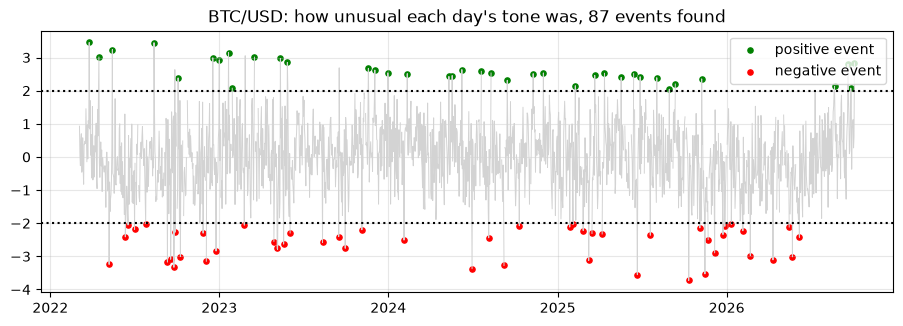

In [8]:
s = symbols[0]
frame = inputs[s]
z = event_study.zscore(frame["tone"])
events = event_study.find_events(z)
fig, ax = plt.subplots()
ax.plot(z.index, z.values, color="lightgrey", linewidth=0.7)
ax.scatter(z.index[[e.position for e in events if e.sign > 0]], [z.iloc[e.position] for e in events if e.sign > 0], color="green", s=14, label="positive event")
ax.scatter(z.index[[e.position for e in events if e.sign < 0]], [z.iloc[e.position] for e in events if e.sign < 0], color="red", s=14, label="negative event")
ax.axhline(2, color="black", linestyle=":"), ax.axhline(-2, color="black", linestyle=":")
ax.set(title=f"{s}: how unusual each day's tone was, {len(events)} events found")
ax.legend();

### Step 2: the average price path around those days

For each event, the price move from the day before to three days after, with the
market's usual drift removed. Green: after unusually positive news. Red: after
unusually negative news. Dashed: the same measure around ordinary days in similar
market states, which is what "no effect" looks like.

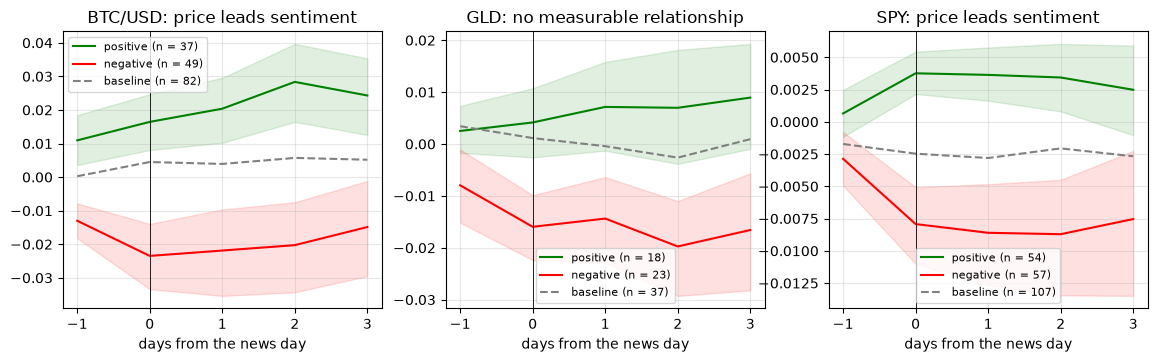

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, s in zip(axes, symbols):
    study = studies[s]
    for key, colour, style in (("positive", "green", "-"), ("negative", "red", "-"), ("baseline", "grey", "--")):
        path = study[key]
        if path["n"]:
            ax.plot(path["offsets"], path["mean"], color=colour, linestyle=style, label=f"{key} (n = {path['n']})")
            if key != "baseline":
                ax.fill_between(path["offsets"], path["low"], path["high"], color=colour, alpha=0.12)
    ax.axvline(0, color="black", linewidth=0.6)
    ax.set(title=f"{s}: {study['verdict']}", xlabel="days from the news day", xticks=[-1, 0, 1, 2, 3])
    ax.legend(fontsize=8)

**How to read this.** If news moved price, the lines would keep separating **after**
day 0. Where most of the move is already there by day 0, the price moved with or
before the news.

### Step 3: which came first?

The correlation between a day's tone and the return a few days apart. Bars on the
left: price moved first. Bars on the right: news came first. Dark bars are larger than
chance would give, allowing for the number of lags tested.

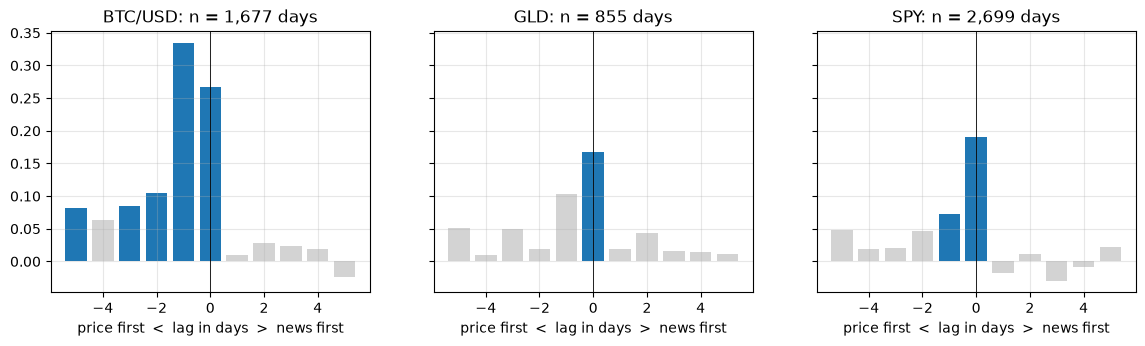

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4), sharey=True)
for ax, s in zip(axes, symbols):
    lags = pd.DataFrame(studies[s]["lags"])
    ax.bar(lags["lag"], lags["correlation"], color=["tab:blue" if x else "lightgrey" for x in lags["significant"]])
    ax.axvline(0, color="black", linewidth=0.6)
    ax.set(title=f"{s}: n = {int(lags['n'].max()):,} days", xlabel="price first  <  lag in days  >  news first")

### The verdicts

The rule: fewer than 30 events means no verdict. Otherwise, whichever side has the
stronger significant correlation leads; if neither side has one, there is no
measurable relationship. The same-day bar is ignored, since it cannot show which came
first.

In [11]:
pd.DataFrame(
    {
        s: {
            "events": studies[s]["n_events"],
            "positive": studies[s]["n_positive"],
            "negative": studies[s]["n_negative"],
            "days with news": studies[s]["days_with_news"],
            "verdict": studies[s]["verdict"],
        }
        for s in symbols
    }
).T

,events,positive,negative,days with news,verdict
BTC/USD,87,38,49,1677,price leads sentiment
GLD,41,18,23,855,no measurable relationship
SPY,111,54,57,2699,price leads sentiment


In [12]:
rows = [{"market": s, **t} for s in symbols for t in studies[s].get("by_topic", [])]
pd.DataFrame(rows).pivot(index="topic", columns="market", values="verdict") if rows else "Topics not yet assigned."

market,BTC/USD,GLD,SPY
topic,,,
adoption,no measurable relationship,not enough events,no measurable relationship
funds_flows,no measurable relationship,not enough events,no measurable relationship
macro,not enough events,not enough events,no measurable relationship
other,no measurable relationship,not enough events,no measurable relationship
price,price leads sentiment,not enough events,price leads sentiment
regulation,not enough events,not enough events,no measurable relationship
security,not enough events,NaN,not enough events


## What to take from this

- Where there is enough news to judge, tone follows price more than it leads it. News
  written after a big move describes the move.
- Gold has too few strong-tone days for a verdict, and the app shows that instead of a
  weak answer.
- All articles come from one provider, and tone models misread sarcasm, negation, and
  headlines that only report a price.